<a href="https://colab.research.google.com/github/Luck-RD/Analise-Exploratoria-e-Visualizacao-de-Dados/blob/main/projetoVisu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/USD_BRL_hist.csv')

In [ ]:
df['Data'] = pd.to_datetime(df['Data'], format='%d.%m.%Y')

In [ ]:
df['Ano'] = df['Data'].dt.year

In [ ]:
df = df.sort_values('Data').reset_index(drop=True)

In [ ]:
df.head()

,Data,USD_BRL,Ano
0,2010-01-01,1.7430,2010
1,2010-01-04,1.7212,2010
2,2010-01-05,1.7310,2010
3,2010-01-06,1.7325,2010
4,2010-01-07,1.7465,2010


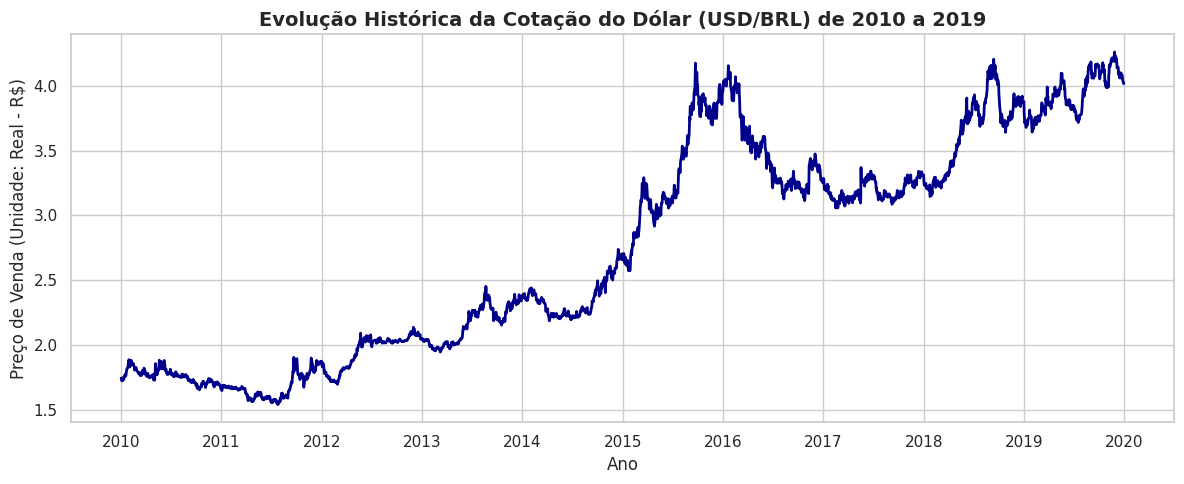

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['Data'], df['USD_BRL'], color='darkblue', linewidth=2)
plt.title('Evolução Histórica da Cotação do Dólar (USD/BRL) de 2010 a 2019', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Preço de Venda (Unidade: Real - R$)', fontsize=12)
plt.tight_layout()
plt.show()

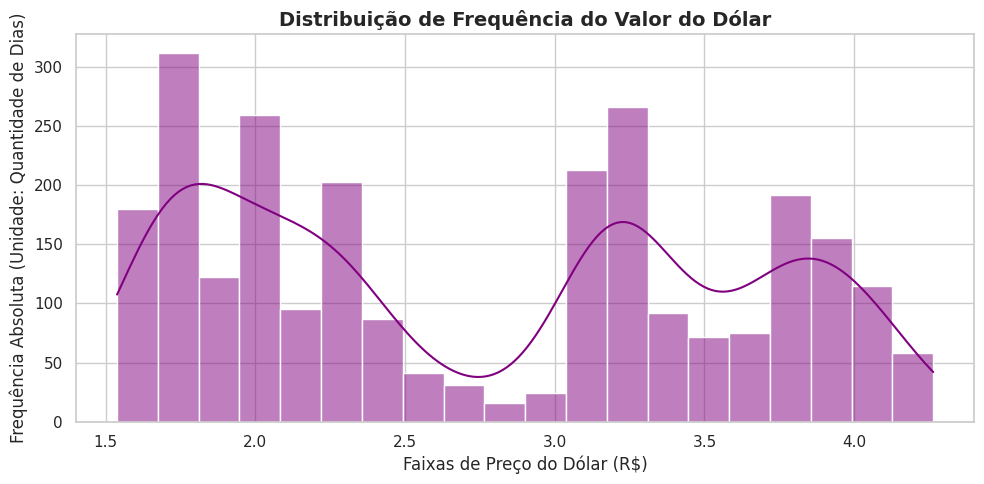

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df['USD_BRL'], bins=20, kde=True, color='purple')

plt.title('Distribuição de Frequência do Valor do Dólar', fontsize=14, fontweight='bold')
plt.xlabel('Faixas de Preço do Dólar (R$)', fontsize=12)
plt.ylabel('Frequência Absoluta (Unidade: Quantidade de Dias)', fontsize=12) # Evidenciando a Unidade de Contagem

plt.tight_layout()
plt.show()

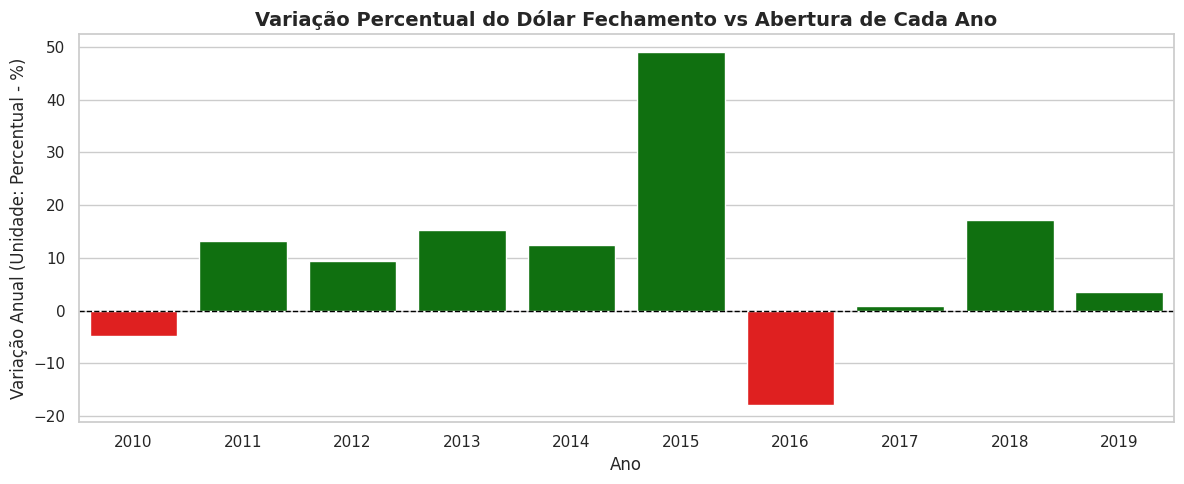

In [ ]:
valores_por_ano = df.groupby('Ano')['USD_BRL'].agg(['first', 'last'])
valores_por_ano['Variacao_Pct'] = ((valores_por_ano['last'] - valores_por_ano['first']) / valores_por_ano['first']) * 100

plt.figure(figsize=(12, 5))

cores = ['green' if x >= 0 else 'red' for x in valores_por_ano['Variacao_Pct']]
sns.barplot(x=valores_por_ano.index, y=valores_por_ano['Variacao_Pct'], palette=cores, hue=valores_por_ano.index, legend=False)

plt.title('Variação Percentual do Dólar Fechamento vs Abertura de Cada Ano', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Variação Anual (Unidade: Percentual - %)', fontsize=12)

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()